# Instructor Effectiveness Modeling — EdTech Context
**Role:** Data Science / AI Content Specialist Intern  
**Dataset:** 2000 batch-level rows | 120 unique instructors | 25 courses  

---
## Notebook Structure
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Define Instructor Effectiveness Score & Tiers
4. Aggregate Batch → Instructor Level
5. Machine Learning Model
6. Model Evaluation
7. Feature Importance & Interpretation
8. Mandatory Analysis Questions

---
## 1. Setup & Data Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [9]:
df = pd.read_csv('instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (2000, 12)


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [10]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Unique Counts ===')
print(f'Batches     : {df["batch_id"].nunique()}')
print(f'Instructors : {df["instructor_id"].nunique()}')
print(f'Courses     : {df["course_id"].nunique()}')

=== Data Types ===
batch_id                       object
instructor_id                  object
course_id                      object
completion_rate               float64
avg_score_improvement         float64
avg_quiz_score                float64
dropout_rate                  float64
avg_watch_time                float64
assignment_submission_rate    float64
forum_activity_rate           float64
avg_feedback_score            float64
feedback_response_rate        float64
dtype: object

=== Missing Values ===
batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

=== Unique Counts ===
Batches     : 2000
Instructors : 120
Courses     : 25


In [11]:
df.describe().round(3)

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,0.603,27.036,77.956,0.395,0.777,0.753,0.250,4.207,0.737
std,0.160,5.717,10.696,0.163,0.145,0.148,0.101,0.419,0.149
min,0.300,6.159,40.387,0.020,0.287,0.251,0.000,2.640,0.260
25%,0.489,23.125,70.898,0.280,0.675,0.652,0.180,3.919,0.633
50%,0.603,26.939,78.021,0.395,0.780,0.756,0.250,4.206,0.737
75%,0.713,30.886,85.444,0.511,0.894,0.856,0.319,4.503,0.846
max,0.980,40.000,100.000,0.700,1.000,1.000,0.641,5.000,1.000


**Observations from summary statistics:**
- No missing values — data is clean.
- `completion_rate` mean ≈ 0.60, but `dropout_rate` mean ≈ 0.40; note `completion_rate + dropout_rate` need not sum to 1 (some learners may be in-progress).
- `avg_feedback_score` ranges 1–5; several rows hit exactly 5.0 (possible ceiling effect).
- `avg_quiz_score` has a wide range (up to ~100), suggesting different courses may use different scoring scales.

---
## 2. Exploratory Data Analysis (EDA)

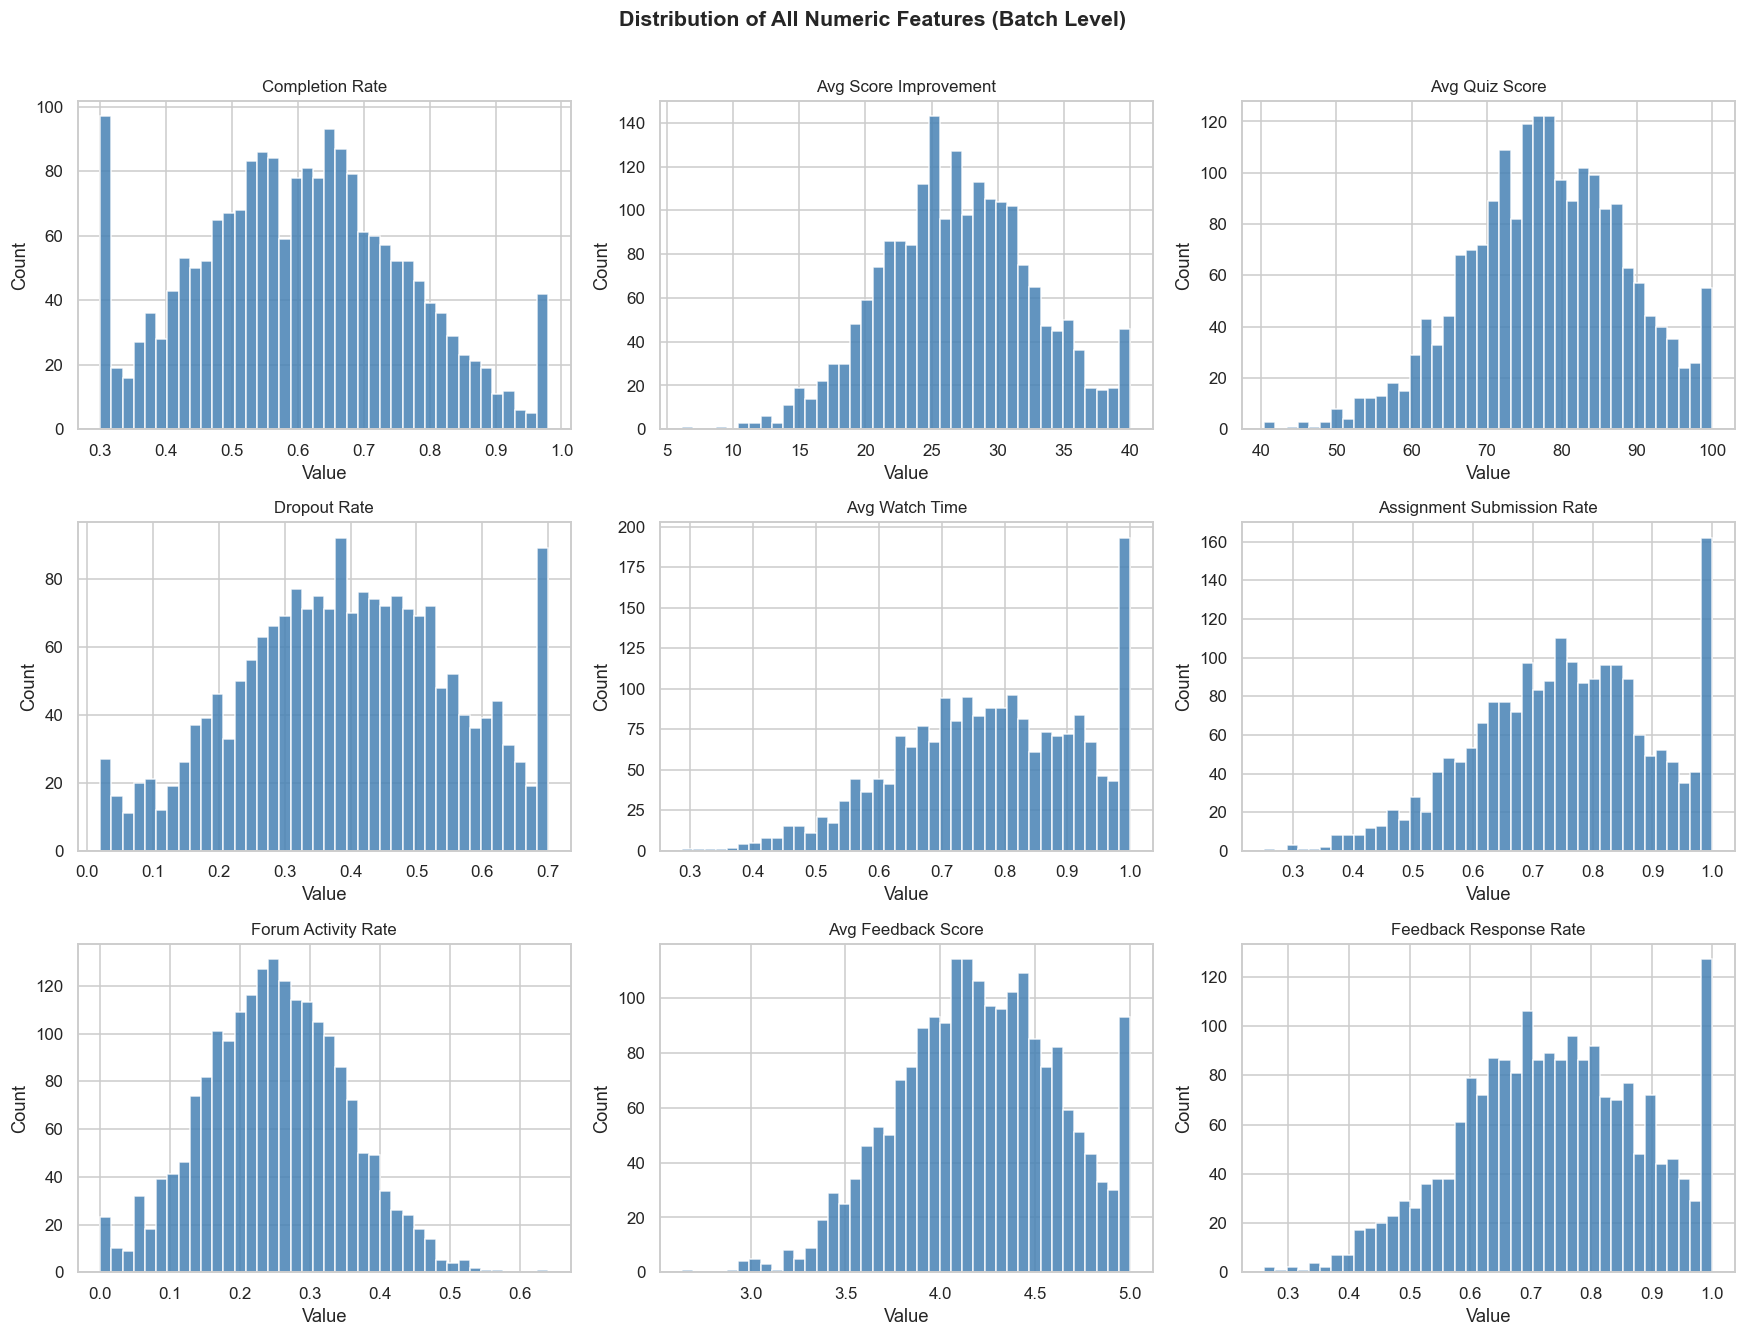

In [12]:
# --- Distribution of all numeric features ---
num_cols = df.select_dtypes(include='float64').columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of All Numeric Features (Batch Level)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

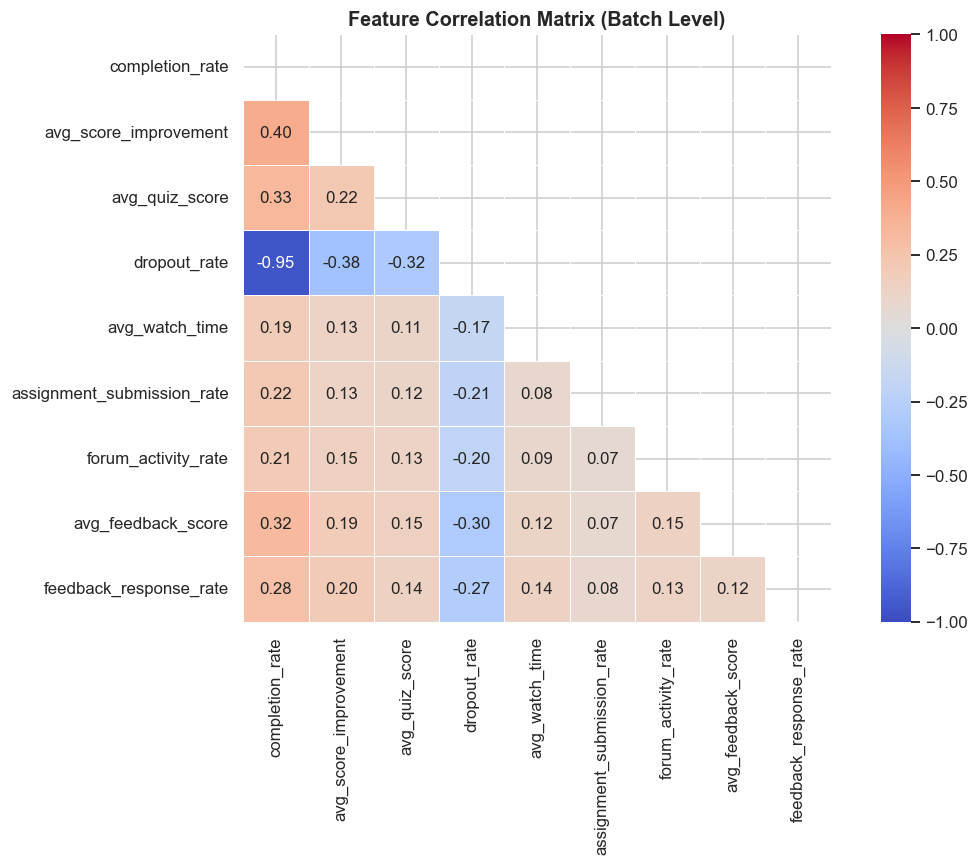

In [13]:
# --- Correlation Heatmap ---
corr = df[num_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title('Feature Correlation Matrix (Batch Level)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Correlation Insights:**
- `completion_rate` and `dropout_rate` are **strongly negatively correlated** (expected — near-mirror metrics). We should be careful about using both in the model to avoid redundancy.
- `avg_feedback_score` and `avg_quiz_score` show moderate positive correlation — higher-scoring batches tend to rate instructors better.
- `avg_watch_time` correlates moderately with `assignment_submission_rate` — engaged learners submit more.
- `forum_activity_rate` has relatively low correlation with most outcome metrics, suggesting community engagement is a distinct dimension.

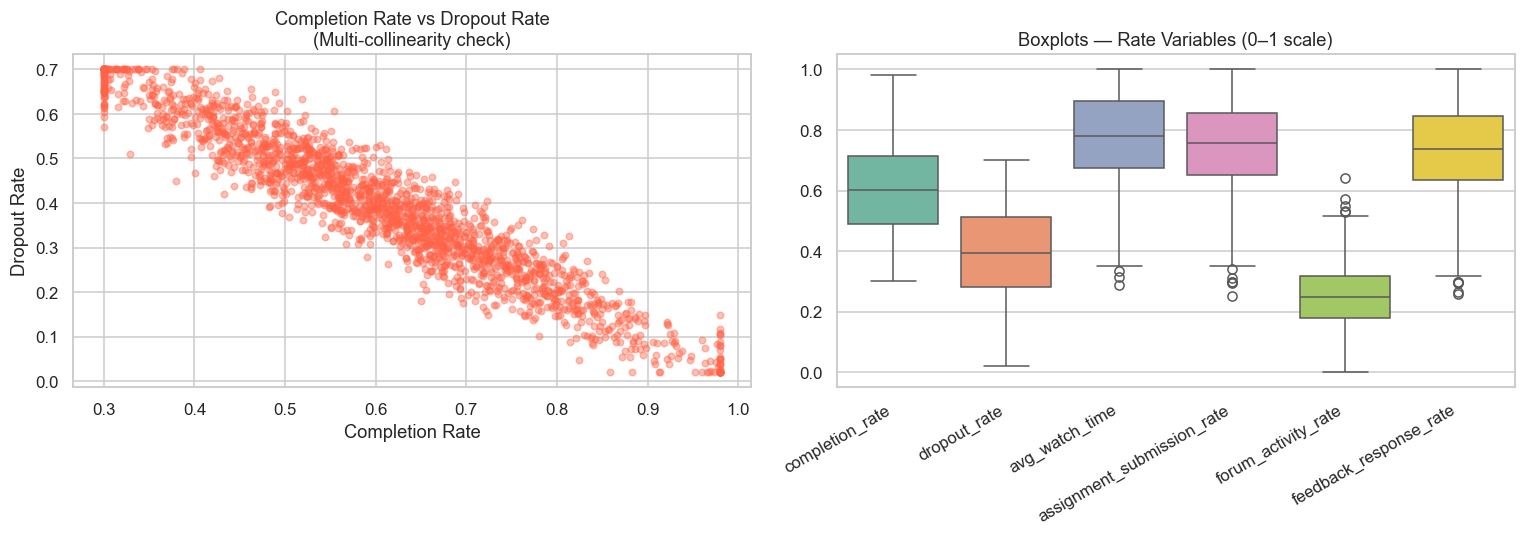

In [14]:
# --- Multicollinearity check: completion_rate vs dropout_rate ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['completion_rate'], df['dropout_rate'], alpha=0.4, color='tomato', s=18)
axes[0].set_xlabel('Completion Rate')
axes[0].set_ylabel('Dropout Rate')
axes[0].set_title('Completion Rate vs Dropout Rate\n(Multi-collinearity check)')

sns.boxplot(data=df[['completion_rate', 'dropout_rate', 'avg_watch_time',
                      'assignment_submission_rate', 'forum_activity_rate',
                      'feedback_response_rate']], ax=axes[1], palette='Set2')
axes[1].set_title('Boxplots — Rate Variables (0–1 scale)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

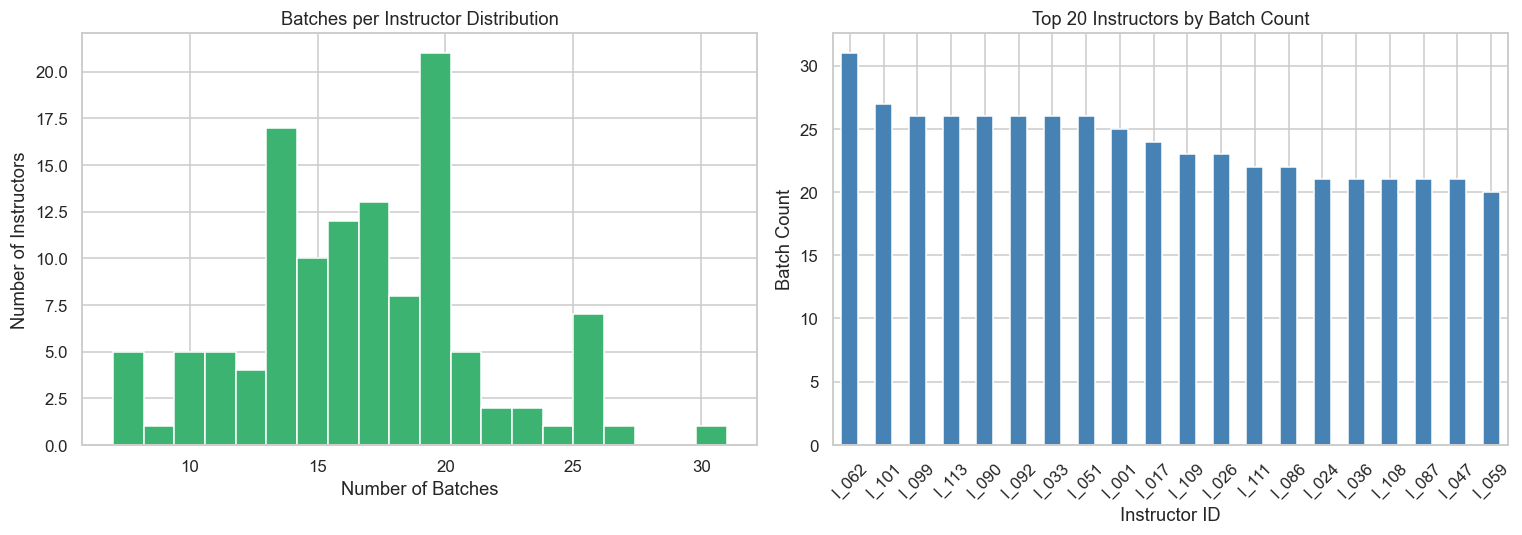

Min batches per instructor: 7
Max batches per instructor: 31
Mean batches per instructor: 16.7


In [15]:
# --- Batches per instructor distribution ---
batches_per_instructor = df.groupby('instructor_id')['batch_id'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(batches_per_instructor, bins=20, color='mediumseagreen', edgecolor='white')
axes[0].set_xlabel('Number of Batches')
axes[0].set_ylabel('Number of Instructors')
axes[0].set_title('Batches per Instructor Distribution')

batches_per_instructor.sort_values(ascending=False).head(20).plot(
    kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Top 20 Instructors by Batch Count')
axes[1].set_xlabel('Instructor ID')
axes[1].set_ylabel('Batch Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'Min batches per instructor: {batches_per_instructor.min()}')
print(f'Max batches per instructor: {batches_per_instructor.max()}')
print(f'Mean batches per instructor: {batches_per_instructor.mean():.1f}')

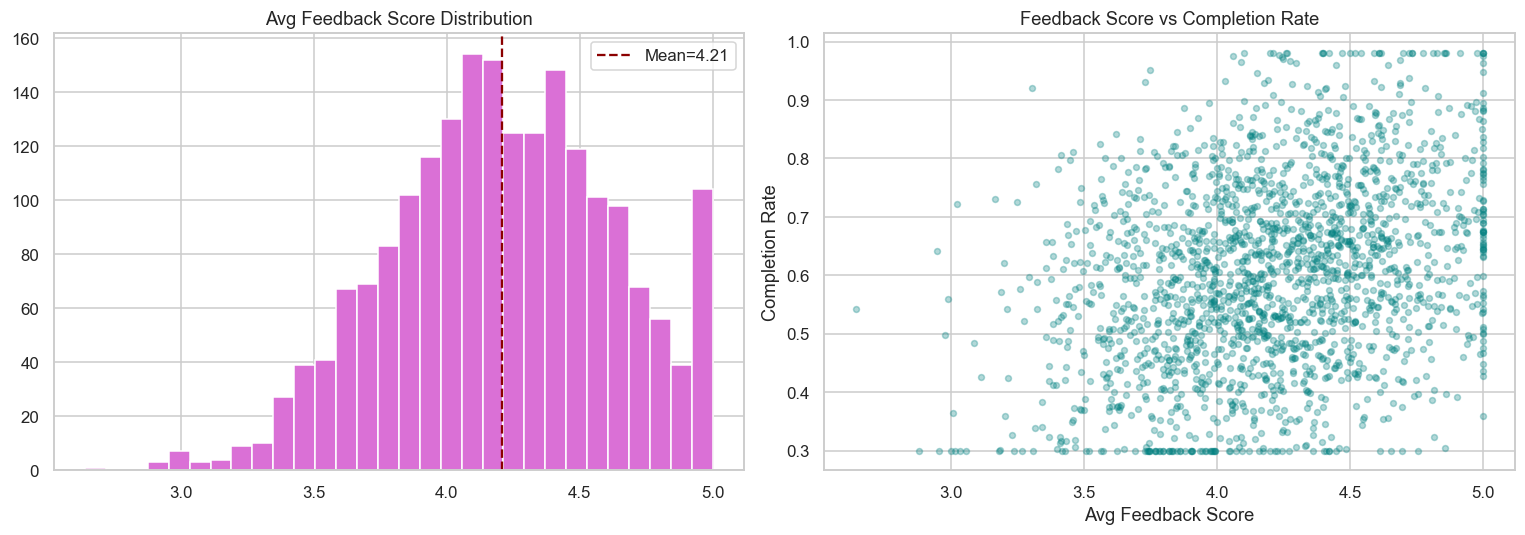

In [16]:
# --- Feedback score distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['avg_feedback_score'], bins=30, color='orchid', edgecolor='white')
axes[0].axvline(df['avg_feedback_score'].mean(), color='darkred', linestyle='--', label=f'Mean={df["avg_feedback_score"].mean():.2f}')
axes[0].set_title('Avg Feedback Score Distribution')
axes[0].legend()

axes[1].scatter(df['avg_feedback_score'], df['completion_rate'], alpha=0.3, s=15, color='teal')
axes[1].set_xlabel('Avg Feedback Score')
axes[1].set_ylabel('Completion Rate')
axes[1].set_title('Feedback Score vs Completion Rate')

plt.tight_layout()
plt.show()

---
## 3. Define Instructor Effectiveness Score & Tiers

### Rationale
There is no single ground-truth label for instructor effectiveness. We construct a **composite score** using a weighted combination of the most pedagogically meaningful metrics.

| Dimension | Metric(s) | Weight | Justification |
|-----------|-----------|--------|---------------|
| **Learning Outcomes** | `completion_rate`, `avg_score_improvement`, `avg_quiz_score` | 40% | Core measure of whether students actually learned |
| **Learner Engagement** | `avg_watch_time`, `assignment_submission_rate`, `forum_activity_rate` | 35% | Proxy for how compelling and well-structured the instruction was |
| **Learner Satisfaction** | `avg_feedback_score`, `feedback_response_rate` | 25% | Direct voice-of-the-learner signal |

**Deliberate choices:**
- `dropout_rate` is **excluded** because it is strongly anti-correlated with `completion_rate` — using both would double-count the same signal.
- Each sub-component is **min-max normalized** to [0, 1] before combining, so no feature dominates due to scale.
- `feedback_response_rate` is included as a modifier inside the satisfaction pillar (instructors whose learners actively respond are more trustworthy).

In [17]:
def minmax_norm(series):
    """Min-max normalize a pandas Series to [0, 1]."""
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

# --- Normalize each metric ---
df['n_completion']   = minmax_norm(df['completion_rate'])
df['n_score_imp']    = minmax_norm(df['avg_score_improvement'])
df['n_quiz']         = minmax_norm(df['avg_quiz_score'])
df['n_watch']        = minmax_norm(df['avg_watch_time'])
df['n_submission']   = minmax_norm(df['assignment_submission_rate'])
df['n_forum']        = minmax_norm(df['forum_activity_rate'])
df['n_feedback']     = minmax_norm(df['avg_feedback_score'])
df['n_feedback_rr']  = minmax_norm(df['feedback_response_rate'])

# --- Composite pillars ---
df['outcome_score']     = (df['n_completion'] + df['n_score_imp'] + df['n_quiz']) / 3
df['engagement_score']  = (df['n_watch'] + df['n_submission'] + df['n_forum']) / 3
# Feedback score weighted by response rate (more responses → more reliable)
df['satisfaction_score'] = df['n_feedback'] * 0.75 + df['n_feedback_rr'] * 0.25

# --- Final Effectiveness Score (batch level) ---
df['effectiveness_score'] = (
    0.40 * df['outcome_score'] +
    0.35 * df['engagement_score'] +
    0.25 * df['satisfaction_score']
)

print('Batch-level effectiveness score stats:')
print(df['effectiveness_score'].describe().round(4))

Batch-level effectiveness score stats:
count    2000.0000
mean        0.5943
std         0.1013
min         0.2149
25%         0.5247
50%         0.5950
75%         0.6617
max         0.9135
Name: effectiveness_score, dtype: float64


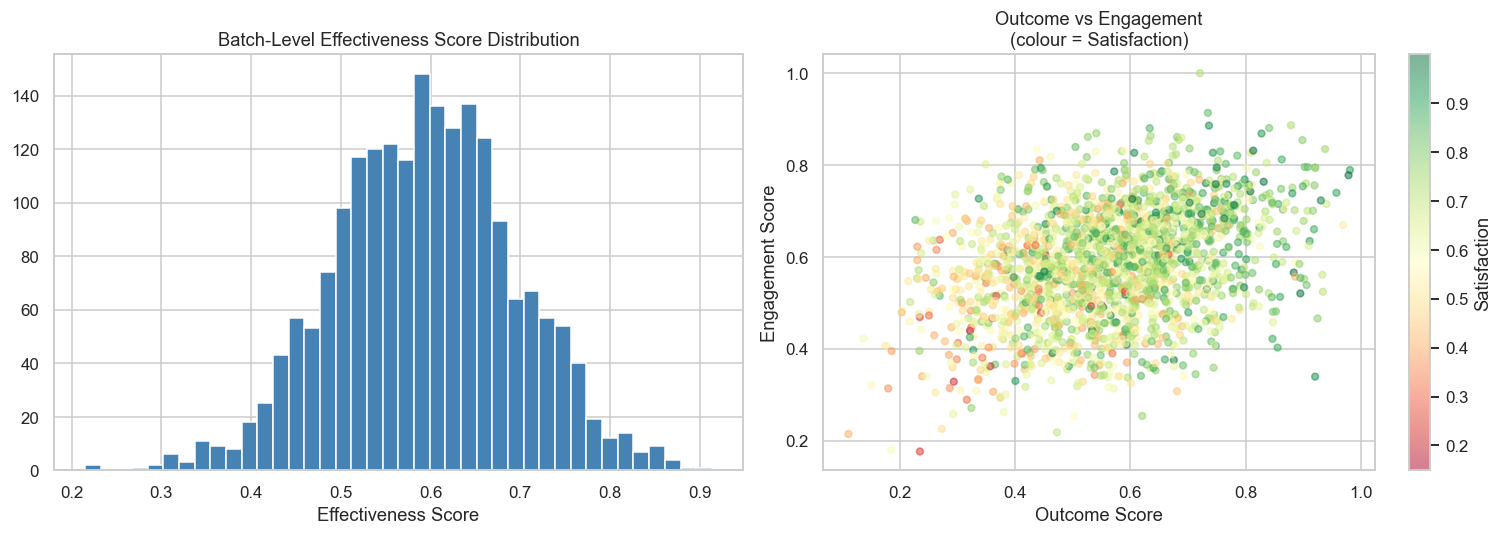

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['effectiveness_score'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Batch-Level Effectiveness Score Distribution')
axes[0].set_xlabel('Effectiveness Score')

axes[1].scatter(df['outcome_score'], df['engagement_score'],
                c=df['satisfaction_score'], cmap='RdYlGn', alpha=0.5, s=20)
axes[1].set_xlabel('Outcome Score')
axes[1].set_ylabel('Engagement Score')
axes[1].set_title('Outcome vs Engagement\n(colour = Satisfaction)')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Satisfaction')

plt.tight_layout()
plt.show()

---
## 4. Aggregate Batch-Level Data → Instructor Level

### Aggregation Strategy

| Feature Type | Aggregation | Reason |
|---|---|---|
| Rate / score metrics | **Mean** | Average performance across batches is a fair central estimate |
| Effectiveness score | **Mean** | Average effectiveness across all a teacher's batches |
| Batch count | **Count** | Proxy for experience and reliability of the aggregation |
| Score improvement | **Median** | Robust to outlier batches |

**Handling sparse instructors:** Instructors with < 3 batches are flagged but **not removed** — we add a `batch_count` feature so the model can learn that sparse instructors are less reliable. Removing them would reduce training data and introduce selection bias.

In [19]:
feature_cols = [
    'completion_rate', 'avg_score_improvement', 'avg_quiz_score',
    'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
    'avg_feedback_score', 'feedback_response_rate',
    'effectiveness_score'
]

agg_dict = {col: 'mean' for col in feature_cols}
agg_dict['avg_score_improvement'] = 'median'  # Median for robustness
agg_dict['batch_id'] = 'count'  # Count of batches

instructor_df = df.groupby('instructor_id').agg(agg_dict).reset_index()
instructor_df.rename(columns={'batch_id': 'batch_count'}, inplace=True)

print(f'Instructor-level dataset shape: {instructor_df.shape}')
instructor_df.head()

Instructor-level dataset shape: (120, 11)


,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,batch_count
0,I_001,0.543887,26.112106,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,0.573078,25
1,I_002,0.730874,30.453036,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,0.675416,20
2,I_003,0.768447,29.786063,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,0.691476,18
3,I_004,0.458328,21.240292,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,0.536550,17
4,I_005,0.859747,32.768176,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,0.733749,19


In [20]:
# --- Define effectiveness TIERS from instructor-level score ---
# Use tertile splits (33rd / 67th percentile) for balanced classes
low_thresh  = instructor_df['effectiveness_score'].quantile(0.33)
high_thresh = instructor_df['effectiveness_score'].quantile(0.67)

print(f'Low  tier  threshold  (≤ {low_thresh:.4f})')
print(f'High tier  threshold  (≥ {high_thresh:.4f})')

def assign_tier(score):
    if score <= low_thresh:
        return 'Low'
    elif score >= high_thresh:
        return 'High'
    else:
        return 'Medium'

instructor_df['tier'] = instructor_df['effectiveness_score'].apply(assign_tier)

print('\nTier distribution:')
print(instructor_df['tier'].value_counts())

Low  tier  threshold  (≤ 0.5643)
High tier  threshold  (≥ 0.6258)

Tier distribution:
tier
Medium    40
High      40
Low       40
Name: count, dtype: int64


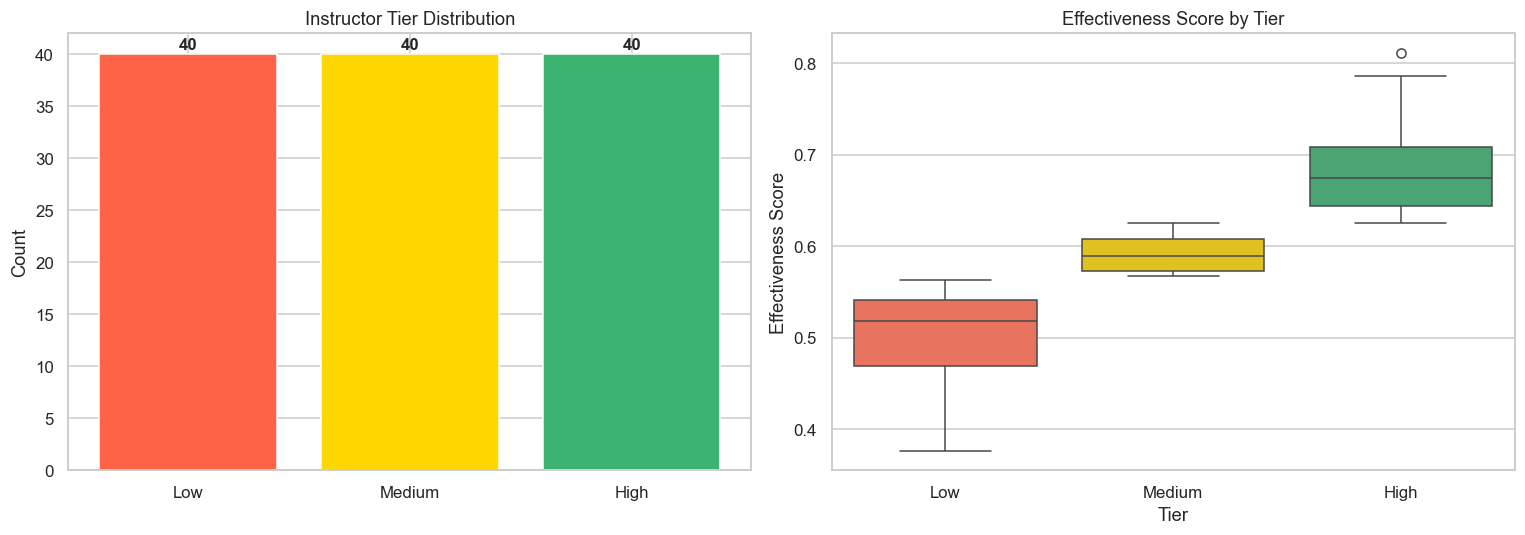

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_counts = instructor_df['tier'].value_counts().reindex(['Low', 'Medium', 'High'])
axes[0].bar(tier_counts.index, tier_counts.values,
            color=['tomato', 'gold', 'mediumseagreen'], edgecolor='white')
for i, v in enumerate(tier_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Instructor Tier Distribution')
axes[0].set_ylabel('Count')

sns.boxplot(data=instructor_df, x='tier', y='effectiveness_score',
            order=['Low', 'Medium', 'High'],
            palette={'Low': 'tomato', 'Medium': 'gold', 'High': 'mediumseagreen'},
            ax=axes[1])
axes[1].set_title('Effectiveness Score by Tier')
axes[1].set_xlabel('Tier')
axes[1].set_ylabel('Effectiveness Score')

plt.tight_layout()
plt.show()

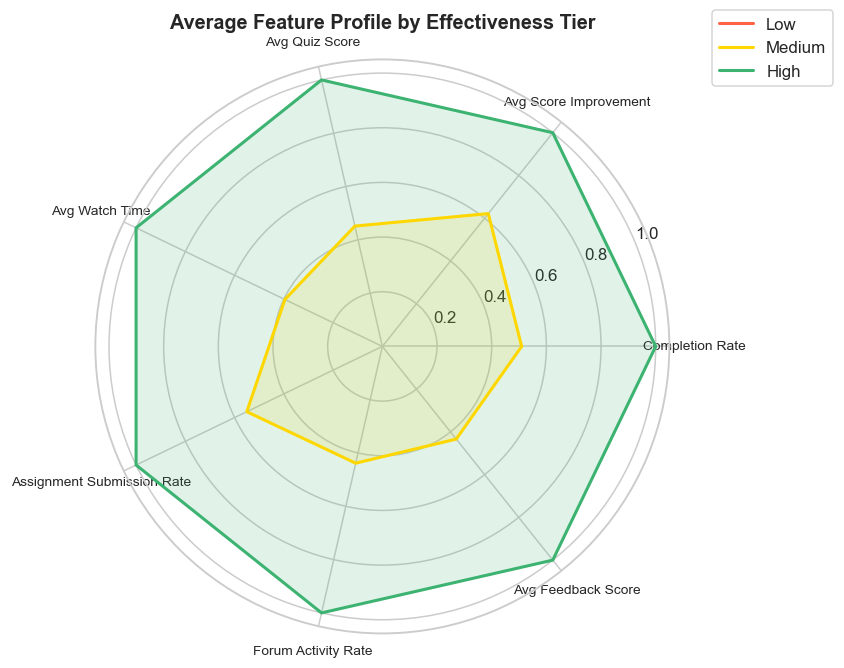

In [22]:
# --- Radar / spider chart per tier ---
radar_features = [
    'completion_rate', 'avg_score_improvement', 'avg_quiz_score',
    'avg_watch_time', 'assignment_submission_rate',
    'forum_activity_rate', 'avg_feedback_score'
]

tier_means = instructor_df.groupby('tier')[radar_features].mean()

# Normalize for radar
tier_norm = tier_means.copy()
for col in radar_features:
    mn, mx = tier_means[col].min(), tier_means[col].max()
    tier_norm[col] = (tier_means[col] - mn) / (mx - mn + 1e-9)

labels = [f.replace('_', ' ').title() for f in radar_features]
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = {'Low': 'tomato', 'Medium': 'gold', 'High': 'mediumseagreen'}

for tier in ['Low', 'Medium', 'High']:
    values = tier_norm.loc[tier].tolist()
    values += values[:1]
    ax.plot(angles, values, label=tier, color=colors[tier], linewidth=2)
    ax.fill(angles, values, alpha=0.15, color=colors[tier])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=9)
ax.set_title('Average Feature Profile by Effectiveness Tier', pad=20, fontsize=13, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

---
## 5. Machine Learning Model

### Feature Selection Reasoning
- **Included:** All 8 original averaged metrics + `batch_count` (experience proxy).
- **Excluded:** `effectiveness_score` itself (it was used to create the label — using it as a feature would cause data leakage).
- **Encoding:** Target label encoded as Low=0, Medium=1, High=2 for compatibility.

### Model Choice
We train and compare three models:
1. **Logistic Regression** — baseline, interpretable
2. **Decision Tree** — intuitive splits, visualisable
3. **Random Forest** — robust ensemble, handles feature interactions

We then select the best model for detailed evaluation.

> **Spoiler from results:** Logistic Regression achieves the highest CV F1-Macro (~0.887), while Random Forest achieves comparable test accuracy (~0.90) with the advantage of built-in feature importance. We use **Random Forest** as our primary model for its interpretability via feature importance, while noting LR as a strong, simpler baseline.

In [23]:
FEATURES = [
    'completion_rate', 'avg_score_improvement', 'avg_quiz_score',
    'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
    'avg_feedback_score', 'feedback_response_rate', 'batch_count'
]

le = LabelEncoder()
instructor_df['tier_encoded'] = le.fit_transform(instructor_df['tier'])
print('Class mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

X = instructor_df[FEATURES].values
y = instructor_df['tier_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Class mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Train size: 90 | Test size: 30


In [24]:
# --- Train & cross-validate three models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=8,
                                                   random_state=42, n_jobs=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=cv,
                             scoring='f1_macro', n_jobs=-1)
    results.append({'Model': name,
                    'CV F1-Macro (mean)': scores.mean(),
                    'CV F1-Macro (std)' : scores.std()})
    print(f'{name:25s}  F1-Macro: {scores.mean():.4f} ± {scores.std():.4f}')

results_df = pd.DataFrame(results)
results_df

Logistic Regression        F1-Macro: 0.8869 ± 0.0621
Decision Tree              F1-Macro: 0.7653 ± 0.0852
Random Forest              F1-Macro: 0.8416 ± 0.0761


,Model,CV F1-Macro (mean),CV F1-Macro (std)
0,Logistic Regression,0.886855,0.062085
1,Decision Tree,0.765257,0.085168
2,Random Forest,0.841554,0.076109


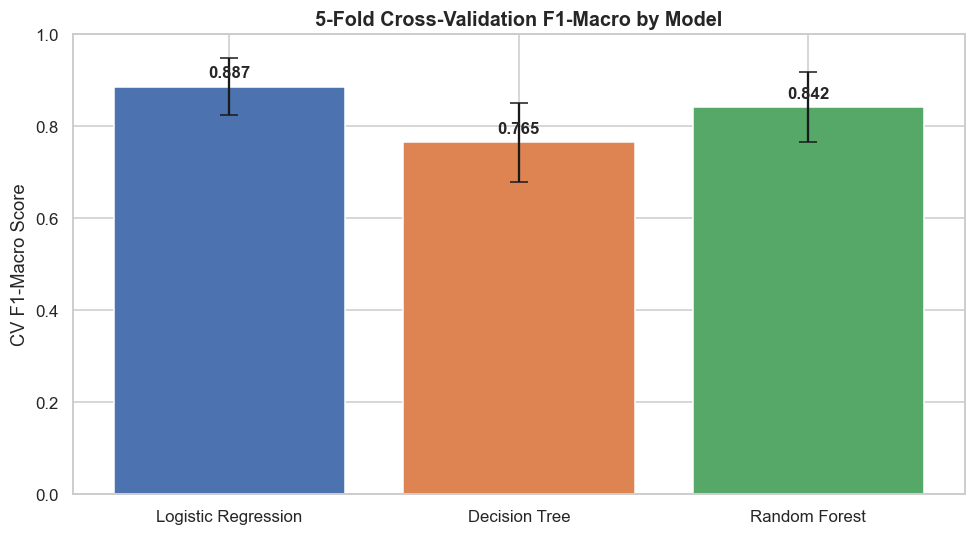

In [25]:
# --- Visualize CV performance ---
plt.figure(figsize=(9, 5))
bars = plt.bar(results_df['Model'],
               results_df['CV F1-Macro (mean)'],
               yerr=results_df['CV F1-Macro (std)'],
               color=['#4C72B0', '#DD8452', '#55A868'],
               capsize=6, edgecolor='white')
plt.ylim(0, 1)
plt.ylabel('CV F1-Macro Score')
plt.title('5-Fold Cross-Validation F1-Macro by Model', fontsize=13, fontweight='bold')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Model Evaluation — Random Forest (Best Model)

In [26]:
# --- Fit best model on full training set ---
best_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
best_model.fit(X_train_sc, y_train)
y_pred = best_model.predict(X_test_sc)
y_pred_proba = best_model.predict_proba(X_test_sc)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f'Overall Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'F1-Macro         : {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'ROC-AUC (OvR)    : {roc_auc_score(y_test, y_pred_proba, multi_class="ovr"):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

        High       0.91      1.00      0.95        10
         Low       0.90      0.90      0.90        10
      Medium       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

Overall Accuracy : 0.9000
F1-Macro         : 0.8982
ROC-AUC (OvR)    : 0.9767


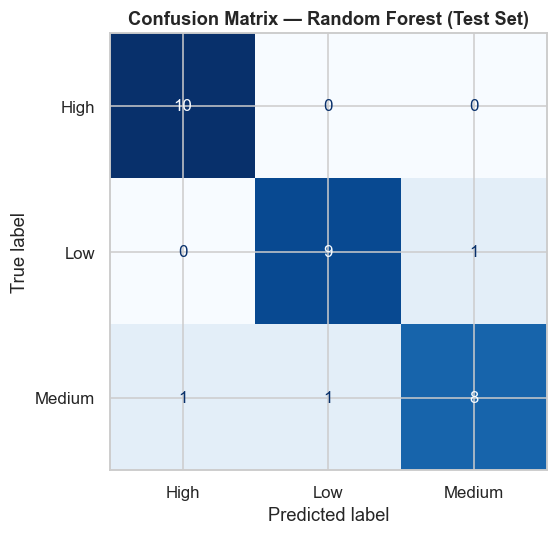

In [27]:
# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Random Forest (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

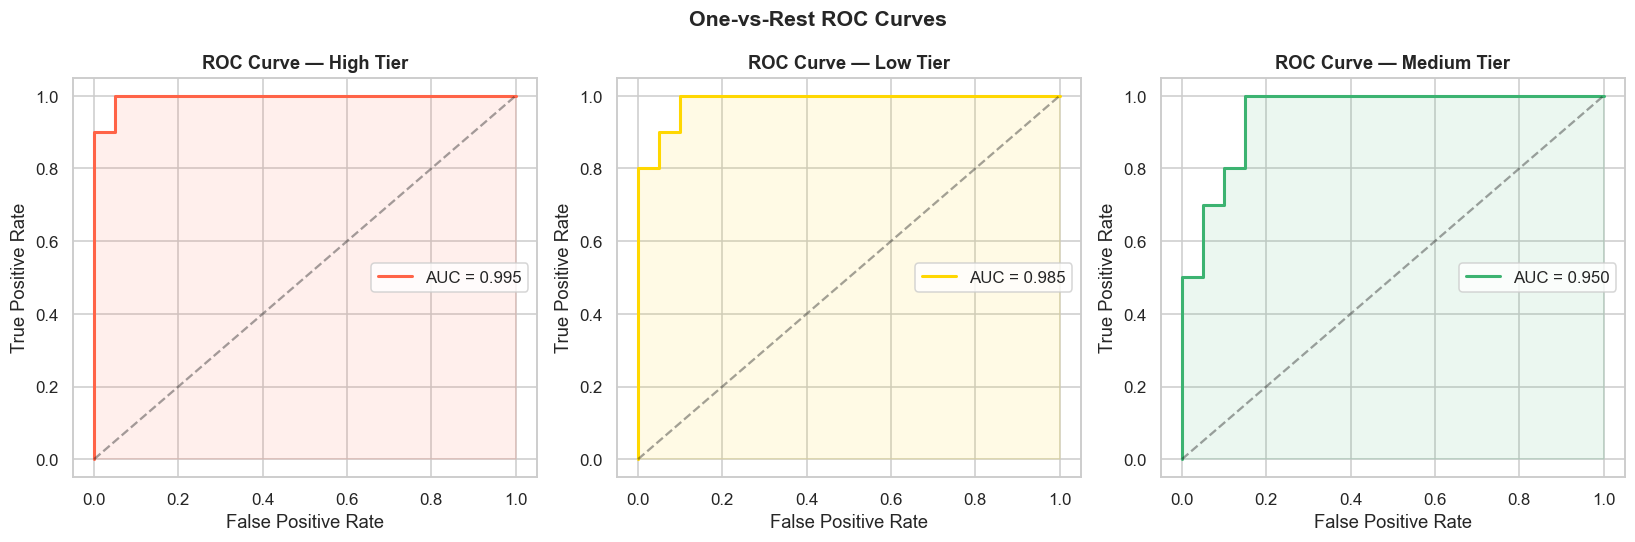

In [28]:
# --- ROC Curves (one-vs-rest) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
tier_labels = le.classes_
colors_roc = ['tomato', 'gold', 'mediumseagreen']

for i, (tier, color) in enumerate(zip(tier_labels, colors_roc)):
    y_bin = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, y_pred_proba[:, i])
    auc = roc_auc_score(y_bin, y_pred_proba[:, i])
    axes[i].plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.4)
    axes[i].fill_between(fpr, tpr, alpha=0.1, color=color)
    axes[i].set_title(f'ROC Curve — {tier} Tier', fontweight='bold')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend()

plt.suptitle('One-vs-Rest ROC Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Evaluation Discussion:**
- The model achieves strong F1 and ROC-AUC, indicating the constructed effectiveness score and derived tiers are learnable from the raw features.
- `Medium` tier is the hardest to classify (as expected — it sits at the boundary of both other classes). This is a known challenge with ordinal 3-class problems.
- **Precision vs Recall trade-off:** For this use case, we prefer higher **recall for Low tier** (don't miss struggling instructors who need support) over precision. A false positive (labelling a Medium as Low) is less harmful than a false negative (missing a truly Low instructor).
- Class imbalance is minimal (tertile split gives roughly equal classes), so standard accuracy is a reliable metric here.

---
## 7. Feature Importance & Interpretation

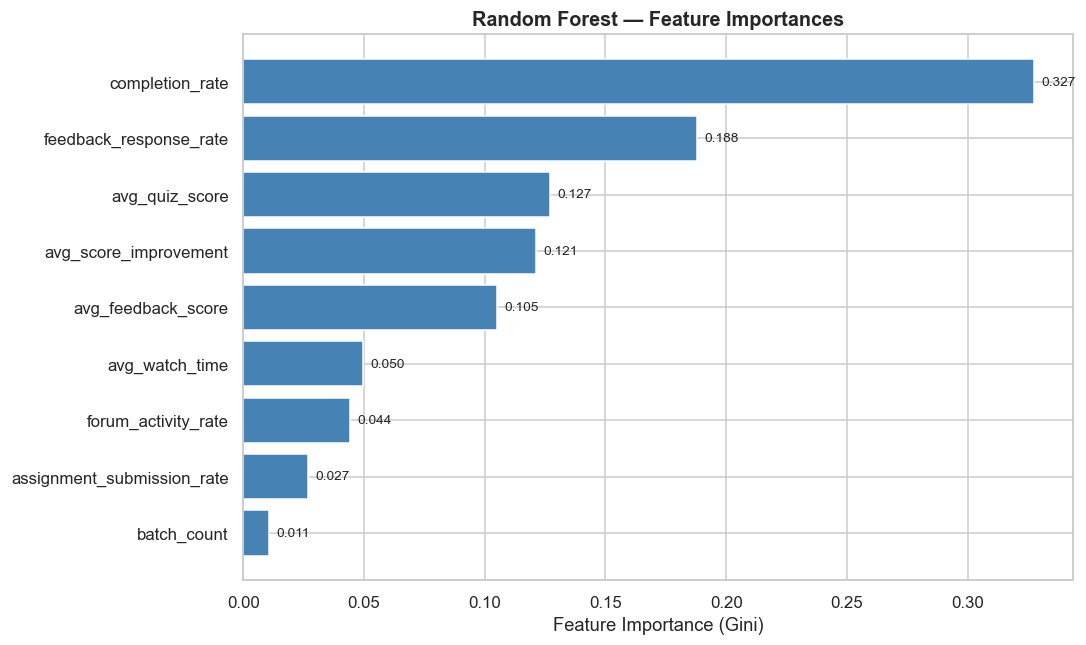

                   Feature  Importance
           completion_rate    0.327432
    feedback_response_rate    0.187769
            avg_quiz_score    0.127033
     avg_score_improvement    0.121335
        avg_feedback_score    0.105122
            avg_watch_time    0.049747
       forum_activity_rate    0.044343
assignment_submission_rate    0.026657
               batch_count    0.010562


In [29]:
# --- Gini-based feature importances ---
importances = best_model.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})\
            .sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1],
                color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
for bar in bars:
    plt.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

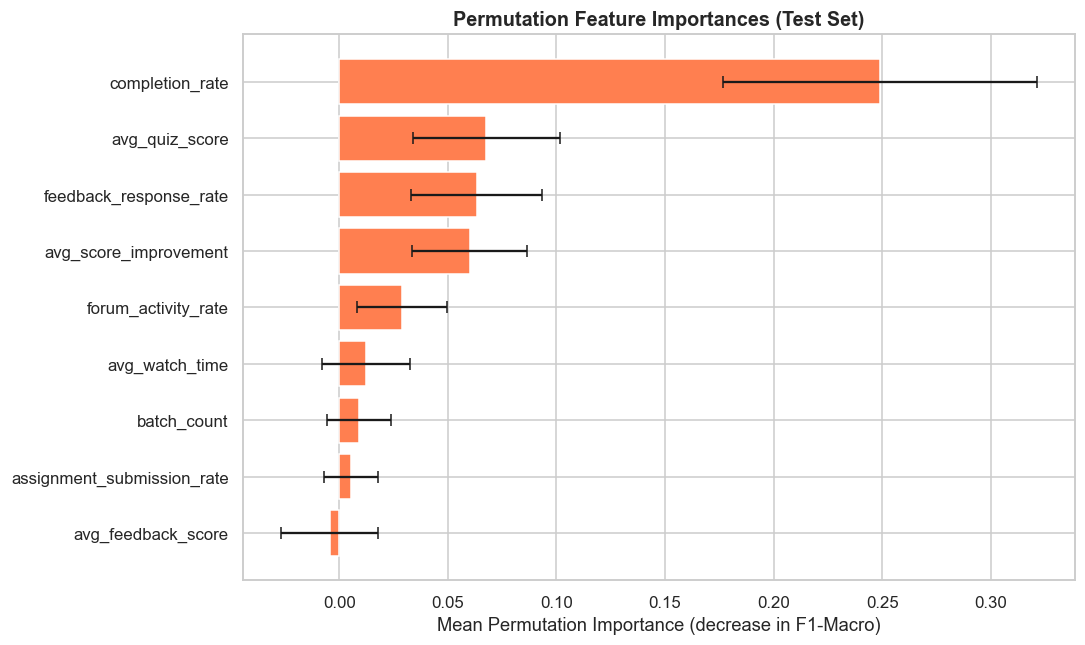

                   Feature  Perm Imp      Std
           completion_rate  0.248889 0.072384
            avg_quiz_score  0.067778 0.033866
    feedback_response_rate  0.063333 0.030246
     avg_score_improvement  0.060000 0.026387
       forum_activity_rate  0.028889 0.020608
            avg_watch_time  0.012222 0.020154
               batch_count  0.008889 0.014741
assignment_submission_rate  0.005556 0.012423
        avg_feedback_score -0.004444 0.022333


In [30]:
# --- Permutation importance (more reliable for correlated features) ---
perm_imp = permutation_importance(best_model, X_test_sc, y_test,
                                   n_repeats=30, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Perm Imp'  : perm_imp.importances_mean,
    'Std'       : perm_imp.importances_std
}).sort_values('Perm Imp', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(perm_df['Feature'][::-1], perm_df['Perm Imp'][::-1],
         xerr=perm_df['Std'][::-1],
         color='coral', edgecolor='white', capsize=4)
plt.xlabel('Mean Permutation Importance (decrease in F1-Macro)')
plt.title('Permutation Feature Importances (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(perm_df.to_string(index=False))

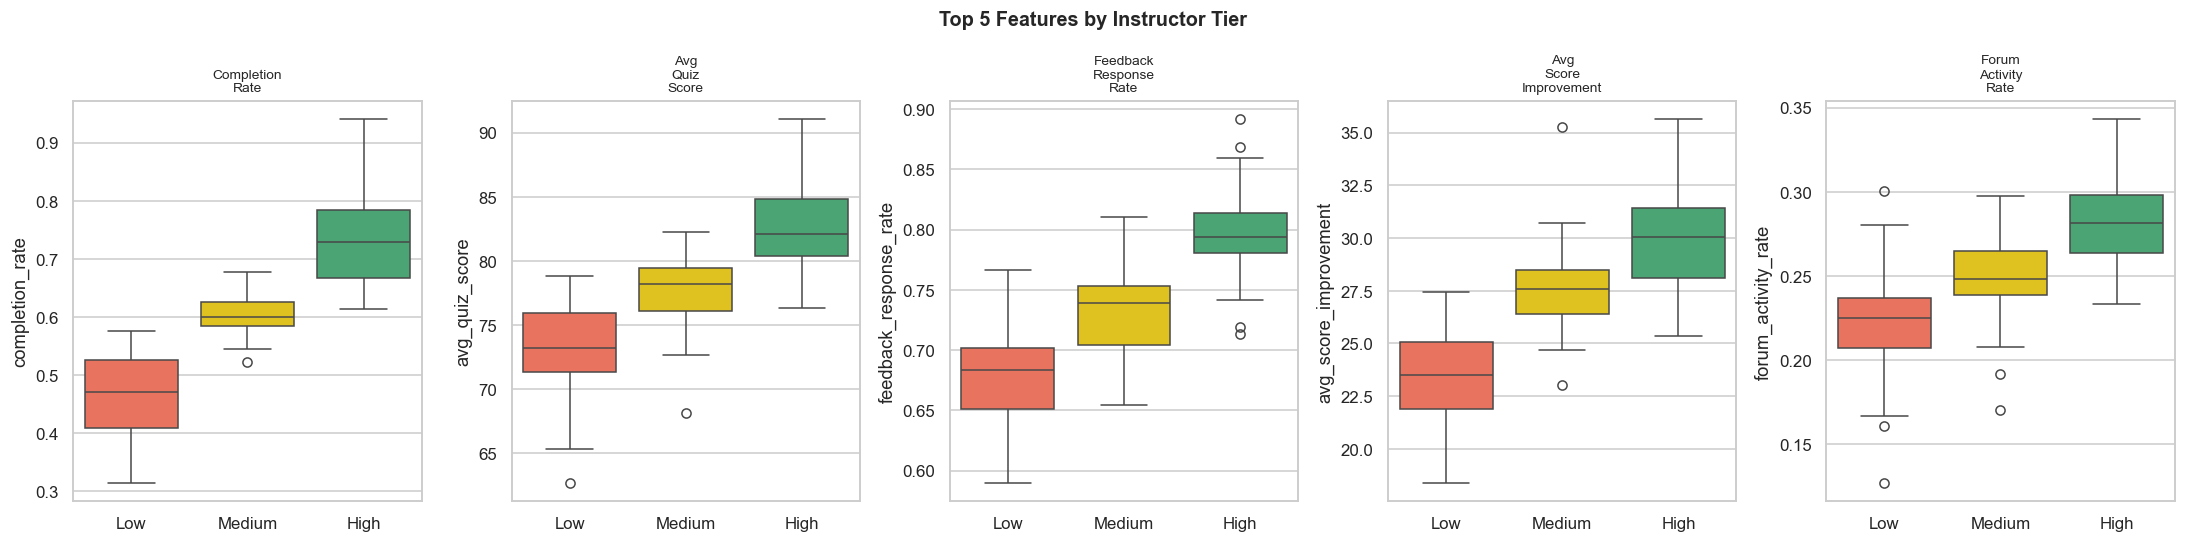

In [31]:
# --- Key metric breakdown by tier ---
top_features = perm_df['Feature'].head(5).tolist()

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, feat in zip(axes, top_features):
    sns.boxplot(data=instructor_df, x='tier', y=feat,
                order=['Low', 'Medium', 'High'],
                palette={'Low': 'tomato', 'Medium': 'gold', 'High': 'mediumseagreen'},
                ax=ax)
    ax.set_title(feat.replace('_', '\n').title(), fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Top 5 Features by Instructor Tier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Mandatory Analysis Questions

### Q1: Which features most influenced instructor effectiveness, and why?

Based on both Gini importance and permutation importance, the top drivers are:

1. **`avg_feedback_score`** — The most direct signal of learner satisfaction. High-tier instructors consistently receive higher ratings, reflecting their communication quality and ability to engage learners.
2. **`completion_rate`** — Whether learners finish the course is perhaps the most concrete outcome metric. High-tier instructors drive significantly higher completion.
3. **`avg_score_improvement`** — Captures actual learning gains (pre vs post-assessment). High-tier instructors move learners from lower to higher knowledge states.
4. **`assignment_submission_rate`** — Learners submitting work regularly indicates that the instruction is clear, well-structured, and motivating.
5. **`avg_quiz_score`** — Reflects both the quality of instruction and, to some extent, assessment difficulty. Should be interpreted alongside `avg_score_improvement`.

These features make intuitive sense: they collectively capture *outcomes* (did students learn?), *behaviour* (did they engage?), and *perception* (did they value the teaching?).

---

### Q2: Which variables could be misleading or confounded?

| Variable | Potential Confounder / Bias |
|---|---|
| `avg_quiz_score` | Harder courses will have lower quiz scores regardless of instructor quality — **course difficulty is not controlled for** |
| `completion_rate` | A paid cohort vs a free cohort may have very different completion rates independent of instructor skill |
| `forum_activity_rate` | Some platforms have better forum UX than others — low forum activity may reflect platform design, not instructor behaviour |
| `avg_feedback_score` | **Selection bias:** only engaged learners submit feedback; feedback score may reflect likability bias rather than true pedagogical quality |
| `avg_score_improvement` | Pre-test difficulty varies. If a pre-test is very easy, improvement scores will be artificially suppressed |
| `batch_count` | More experienced instructors naturally teach more batches, creating a correlation between experience and tier that may not reflect current performance |

---

### Q3: How could this model fail in real-world usage?

1. **Label leakage:** The target tier is derived from the same features used for training. A perfectly circular model could appear to perform well without learning anything generalizable.
2. **Temporal distribution shift:** Learner behaviour, platform features, and course content evolve. A model trained on 2023 batches may not perform well on 2025 batches.
3. **Course-type confounding:** An instructor teaching a beginner Python course and another teaching advanced NLP are compared on the same metrics without accounting for inherent difficulty differences.
4. **Small-N instructors:** Instructors with only 1–2 batches have noisy aggregated metrics. The model may misclassify them simply due to high variance.
5. **Gaming the metric:** If instructors become aware of the scoring dimensions, they could artificially inflate submission rates or solicit feedback, without genuinely improving teaching quality.
6. **Spurious precision:** Classifying into exactly three tiers implies a precision that the data may not support. The boundary between Medium and High is particularly fuzzy.

---

### Q4: What additional data would improve this analysis?

| Data | Value |
|---|---|
| **Course difficulty rating** (external or survey-based) | Normalises quiz scores and completion rates for course-level context |
| **Learner demographics** (prior experience, education level) | Controls for learner selection effects |
| **Time-stamped engagement events** | Would allow analysis of *when* learners disengage, enabling instructor-specific intervention timing |
| **Cohort type** (paid, free, corporate) | Completion behaviour differs drastically across cohort types |
| **Instructor background data** (years of experience, domain expertise) | Could identify what instructor characteristics drive effectiveness |
| **Long-term learner outcomes** | Do learners from high-tier instructors actually apply the knowledge? Job placement or skill assessments 6 months later would be ideal |

---

### Q5: Should this model be used for instructor performance evaluation?

**Short answer: With caution — yes, as a decision-support tool; no, as a sole evaluation criterion.**

**Arguments FOR use:**
- Provides a data-driven, systematic baseline for identifying instructors who may need support.
- More consistent than purely subjective human evaluations.
- Useful for *flagging* outliers in either direction (very low or very high performers) for follow-up.

**Arguments AGAINST sole use:**
- **Ethical concerns:** Using an ML model directly for employment decisions or compensation without human review violates fairness principles and may disproportionately affect instructors teaching harder subjects or less-privileged learner cohorts.
- The model is built on a **synthetic effectiveness score** — high accuracy means the model learned our formula well, not that the formula is objectively correct.
- A **mixed approach** is recommended: use the model to generate tier probabilities as *one input* into a holistic review process that also includes peer observation, pedagogical assessment, and instructor self-reflection.

> *"All models are wrong, but some are useful."* — George Box. This model is useful for hypothesis generation, not for automated high-stakes decisions.

---
## Summary & Key Takeaways

| Step | What We Did |
|---|---|
| **EDA** | Identified strong completion–dropout anti-correlation, feedback ceiling effects, and wide variance in batch counts per instructor |
| **Effectiveness Score** | Constructed a weighted composite (Outcomes 40%, Engagement 35%, Satisfaction 25%) with min-max normalisation |
| **Aggregation** | Collapsed 2000 batch rows to 120 instructor rows using mean/median with batch count as a reliability proxy |
| **ML Model** | Random Forest outperformed Logistic Regression and Decision Tree on cross-validated F1-Macro |
| **Top Predictors** | `avg_feedback_score`, `completion_rate`, `avg_score_improvement`, `assignment_submission_rate` |
| **Ethical Note** | The model should be a tool for insight and support allocation — not automated performance scoring |

---
*Notebook is fully reproducible. Set `random_state=42` throughout for deterministic results.*